In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [20]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [34]:
print(df.sample(5))

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
5     9305-CDSKC  Female              0      No         No       8   
3203  5879-HMFFH  Female              0     Yes         No      72   
6100  3565-UNOCC  Female              1     Yes         No      29   
259   5046-NUHWD  Female              1     Yes         No      29   
826   3643-AHCFP    Male              1     Yes         No       7   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
5             Yes               Yes     Fiber optic             No  ...   
3203          Yes               Yes             DSL            Yes  ...   
6100          Yes               Yes     Fiber optic             No  ...   
259            No  No phone service             DSL            Yes  ...   
826           Yes               Yes     Fiber optic             No  ...   

     DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
5                 Yes          No         Yes  

In [22]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [24]:
print(df.isnull().sum())
print(df.describe(include="all"))
print(df.duplicated().sum()) # duplicate

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
        customerID gender  SeniorCitizen Partner Dependents       tenure  \
count         7043   7043    7043.000000    7043       7043  7043.000000   
unique        7043      2            NaN       2          2          NaN   
top     7590-VHVEG   Male            NaN      No         No          NaN   
freq             1   3555            NaN    3641       4933          NaN   
mean           NaN    NaN       0.162147     NaN        NaN    32.371149   
std            NaN    NaN       0.368612     NaN

<Axes: xlabel='Churn', ylabel='count'>

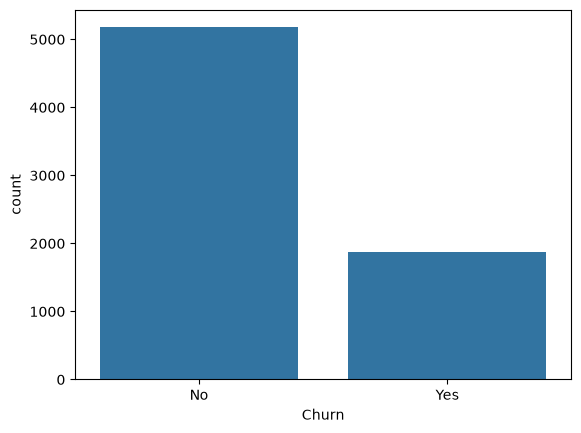

In [25]:
sns.countplot(data=df, x="Churn") # Distribution of churns inside the dataset

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

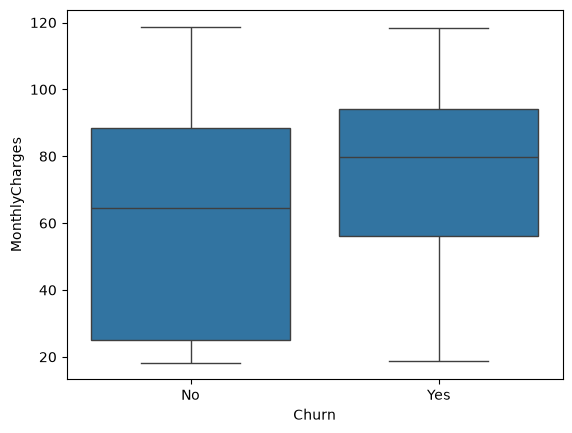

In [26]:
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

The boxplot shows that customers who churn have a noticeably higher median monthly charge than those who remain. Although the distributions overlap, the narrower interquartile range for churning customers indicates that their monthly charges are more consistently concentrated around higher values.

<Axes: xlabel='Churn', ylabel='tenure'>

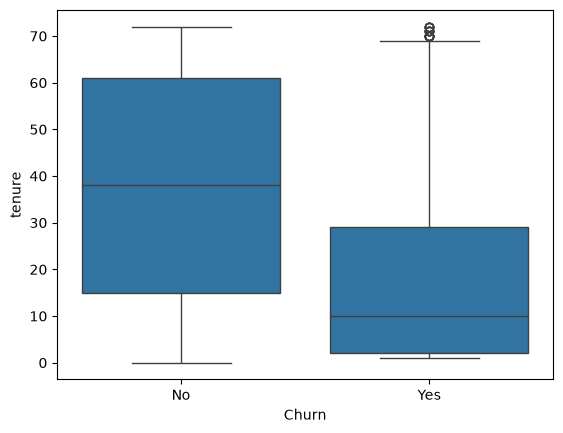

In [27]:
sns.boxplot(data=df, x="Churn", y="tenure")

That boxplot shows that customers who churn have a lower median tenure (months the customer stayed at the company) than the others. The distribution overlaps. Interquartile range for the customers who churn underlines that the tenure is concentrated around lower values. There are outliers for customers who churns with high tenure showing that very few loyal customers are churning.

<Axes: xlabel='Contract', ylabel='count'>

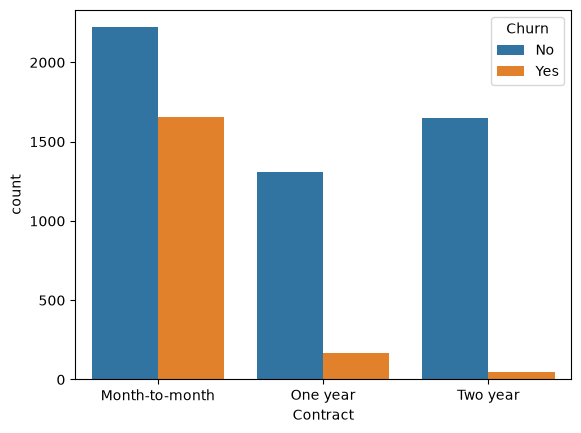

In [28]:
sns.countplot(data=df, x="Contract", hue="Churn")

Customers with a month-to-month contract exhibit a much higher churn rate than customers with one-year or two-year contracts.

<Axes: xlabel='InternetService', ylabel='count'>

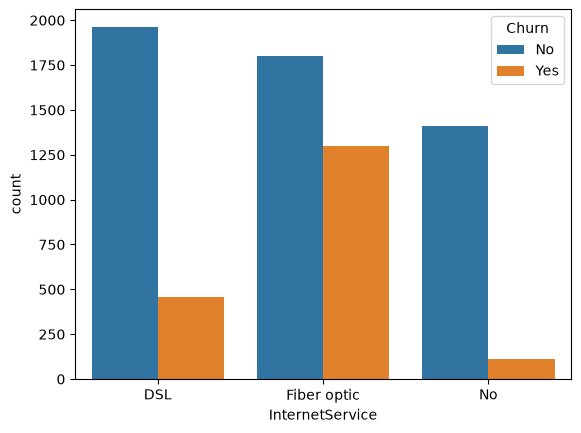

In [29]:
sns.countplot(data=df, x="InternetService", hue="Churn")

Customers using Fiber optic Internet service exhibit a substantially higher churn rate than those using DSL. Customers without Internet service rarely churn.

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

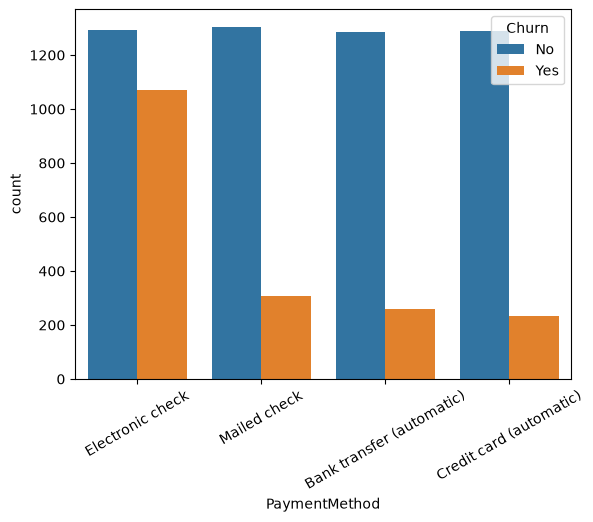

In [30]:
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.xticks(rotation=30)

Customers paying by electronic check exhibit the highest churn rate, whereas automatic payment methods appear to be associated with better customer retention.

<Axes: >

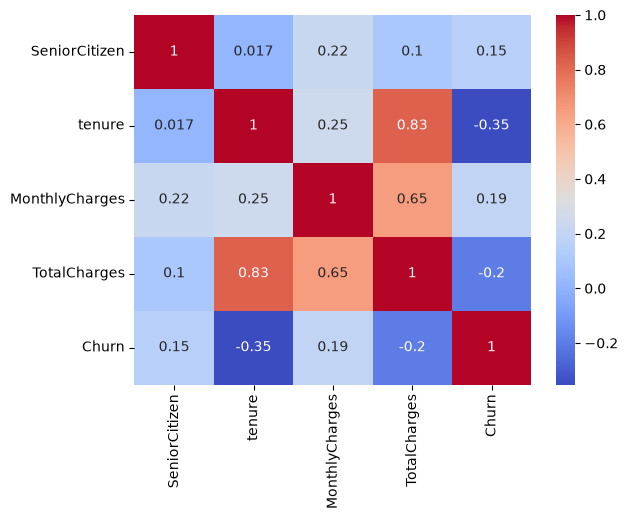

In [33]:
df_corr = df.copy()
df_corr["Churn"] = df_corr["Churn"].map({"No": 0, "Yes": 1})

numerical_columns = df_corr.select_dtypes(include=["int64", "float64"]).columns

sns.heatmap(
    df_corr[numerical_columns].corr(),
    annot=True,
    cmap="coolwarm",
)

The correlation matrix shows that tenure is the numerical feature most negatively correlated with churn, while MonthlyCharges has a weak positive correlation. SeniorCitizen exhibits only a very weak relationship with churn. Strong correlations between tenure and TotalCharges are expected since customers who stay longer naturally accumulate higher total charges.

<Axes: xlabel='tenure', ylabel='Count'>

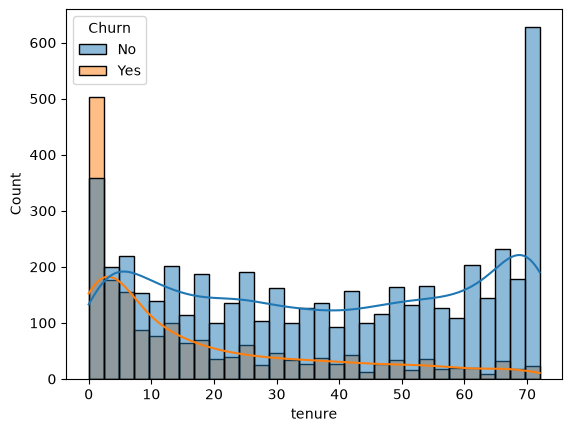

In [32]:
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

Customers with a short tenure are considerably more likely to churn, whereas customers who have stayed with the company for many months are much more likely to remain.